DISCLAIMER : cette liste d'exemples d'illustrations n'est pas exhaustive, et on peut sûrement trouver d'autres bonnes idées pour illustrer les résultats du texte ! A l'inverse, il n'est EVIDEMMENT pas nécessaire de faire autant de simulations le jour J pour s'en sortir avec une bonne note !!

In [3]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy
import csv

In [235]:
P=(1/6)*np.array([[1,1,1,1,1,1,0],[1,0,1,1,1,1,1],[1,0,0,1,1,2,1],[2,0,0,0,1,2,1],[2,0,0,0,1,2,1],[1,0,1,1,1,1,1],[0,0,0,0,0,0,6]])

# Simulations de trajectoires 

In [139]:
def trajectoire(n): # simule une trajectoire de la chaîne avec n pas (on renumérote de 0 à 6)
    X=[0] 
    for _ in range(n):
        X.append(np.random.choice(a=range(len(P)), p=P[X[-1],:]))
    return(np.array(X))

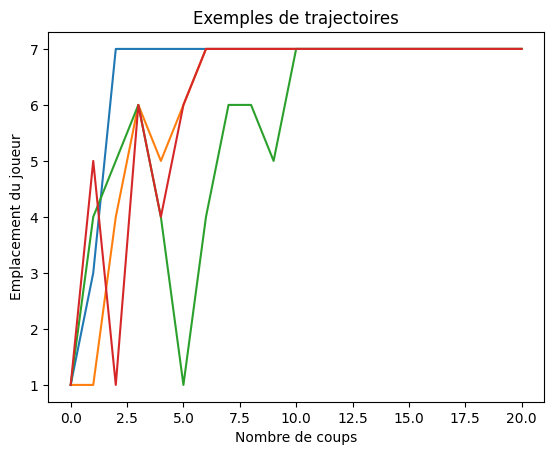

In [316]:
n=20
X1=trajectoire(n)+1 # j'ajoute 1 pour que ce soit numéroté comme dans l'énoncé 
X2=trajectoire(n)+1 
X3=trajectoire(n)+1 
X4=trajectoire(n)+1 
plt.plot(np.arange(0,n+1),X1) 
plt.plot(np.arange(0,n+1),X2) 
plt.plot(np.arange(0,n+1),X3) 
plt.plot(np.arange(0,n+1),X4) 
plt.xlabel('Nombre de coups')
plt.ylabel('Emplacement du joueur')
plt.title('Exemples de trajectoires') 
plt.show()

# Illustration théorème 2 

Une fois la matrice codée, on peut directement s'en servir pour calculer le $d$ et le $\alpha$ nécessaires pour illustrer le théorème 2. 

In [65]:
P2=np.linalg.matrix_power(P,2)
print(P2)

[[0.22222222 0.02777778 0.08333333 0.11111111 0.16666667 0.25
  0.13888889]
 [0.19444444 0.02777778 0.05555556 0.08333333 0.13888889 0.22222222
  0.27777778]
 [0.19444444 0.02777778 0.08333333 0.08333333 0.13888889 0.19444444
  0.27777778]
 [0.16666667 0.05555556 0.11111111 0.11111111 0.13888889 0.16666667
  0.25      ]
 [0.16666667 0.05555556 0.11111111 0.11111111 0.13888889 0.16666667
  0.25      ]
 [0.19444444 0.02777778 0.05555556 0.08333333 0.13888889 0.22222222
  0.27777778]
 [0.         0.         0.         0.         0.         0.
  1.        ]]


Avec les notations du texte, $d=2$. En fait on peut s'en convaincre facilement sans calcul : tous les états menent à 7 en 1 coup sauf le premier, qui peut y mener à partir de 2 coups. On peut maintenant calculer $\alpha$. 

In [262]:
d=2
alpha=np.max(1-P2[:-1,-1])
p=alpha**(1/d)
C=-log(alpha)

On va estimer via Monte-Carlo la proba $\mathbb P (T>n)$ en fonction de $n$, pour ensuite tracer le log de cette proba en fonction de $n$. Pour ça, on a d'abord besoin d'une fonction qui simule un temps d'absorption. 

In [93]:
def temps_abs(): # simule une trajectoire de la chaine de Markov et renvoie son temps d'absorption T (on renumérote de 0 à 6)
    X=[0]
    k=0
    while X[-1]!= 6:
        X.append(np.random.choice(a=range(len(P)), p=P[X[k],:]))
        k+=1
    return(k)

In [56]:
temps_abs()

7

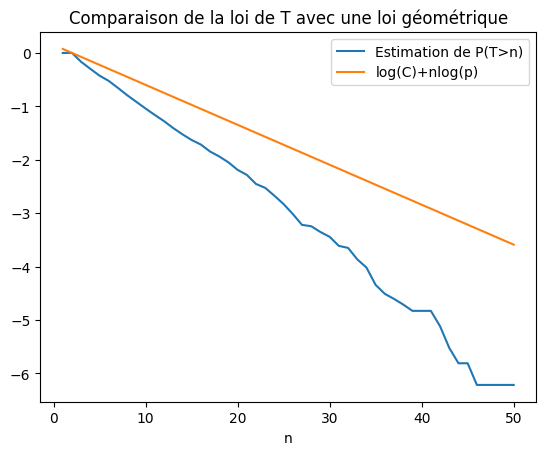

In [272]:
def estim_proba(n,N): # N est la taille de l'échantillon utilisé pour estimer les probas
    P_estim=np.zeros(n) # P va être un tableau d'estimation des P(T>k) en fonction de k, pour k dans [1,n]
    for _ in range (N): 
        t=temps_abs()
        for k in range (0,min(t,n)): 
            P_estim[k]+=1
    return(P_estim/N)

n=50
N=1000
plt.plot(np.arange(1,n+1),np.log(estim_proba(n,N)),label='Estimation de P(T>n)')
P_geom=C+np.arange(1,n+1)*log(p)
plt.plot(np.arange(1,n+1),P_geom,label='log(C)+nlog(p)')
plt.xlabel('n')
plt.title('Comparaison de la loi de T avec une loi géométrique')
plt.legend()
plt.show()

Pour calculer $\mathbb P (T >n)$, la méthode de Monte-Carlo n'est pour le coup pas nécessaire, on peut juste le calculer matriciellement : 
$$\mathbb P (T >n) = \mathbb P(X_n \neq N) = 1 - (\mu_0 P^n)_N,$$
où $\mu_0= (1,0,\dots,0)$. Si vous utilisez une méthode de Monte-Carlo ailleurs, pas besoin de vous embêter à l'utiliser ici. Sinon, je trouve ça pas mal de l'utiliser à un moment pour montrer que vous savez comment vous en servir. 

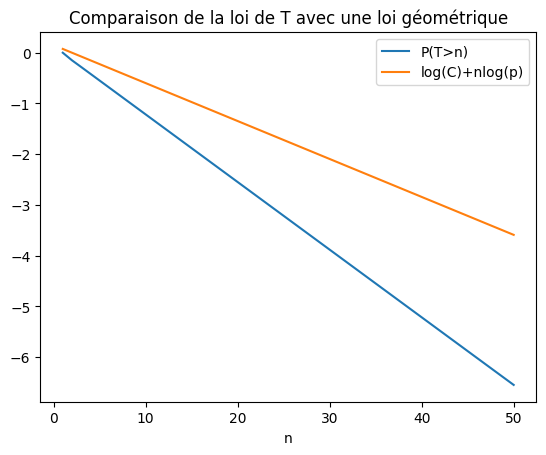

In [271]:
n=50
P_calc=[]
Pk=P # va recevoir les puissances successives de P
mu0=np.zeros(len(P))
mu0[0]=1
for _ in range (n) : 
    P_calc.append(1-mu0.dot(Pk)[-1])
    Pk=P.dot(Pk)

plt.plot(np.arange(1,n+1),np.log(P_calc),label='P(T>n)')
P_geom=C+np.arange(1,n+1)*log(p)
plt.plot(np.arange(1,n+1),P_geom,label='log(C)+nlog(p)')
plt.xlabel('n')
plt.title('Comparaison de la loi de T avec une loi géométrique')
plt.legend()
plt.show()

## Illustration théorème 6 

In [213]:
mu=np.array([0.251,0.048,0.109,0.130,0.190,0.272])
l=0.875
e=8.014

On va illustrer le théorème 6 de plusieurs façons différentes :  avec une comparaison fdr théorique/fdr empirique, avec un diagramme bâtons, avec un test et avec une estimation via Monte-Carlo de la moyenne. 

In [107]:
def temps_abs_mu(): # cette fois ci, on simule un temps d'absorption dans le cas où X_0 suit la loi mu 
    x0=np.random.choice(a=range(len(mu)), p=mu)
    X=[x0]
    k=0
    while X[-1]!= 6:
        X.append(np.random.choice(a=range(len(P)), p=P[X[k],:]))
        k+=1
    return(k)

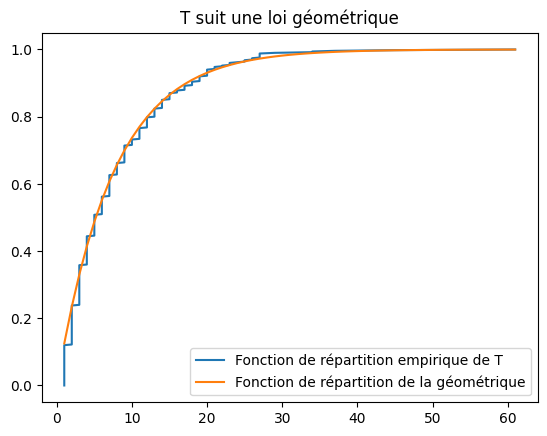

In [279]:
def compraison_fdr(N): # N est la taille de l'échantillon 
    T=np.array([temps_abs_mu() for _ in range (N+1)])
    T_sort=np.sort(T)
    t=np.arange(min(T),max(T)+1)
    F_emp=np.arange(0,N+1)/N 
    F_th=stats.geom.cdf(t,1-l)
    plt.plot(T_sort,F_emp, label='Fonction de répartition empirique de T')
    plt.plot(t,F_th, label='Fonction de répartition de la géométrique')
    plt.title('T suit une loi géométrique')
    plt.legend() 
    plt.show()

compraison_fdr(500)

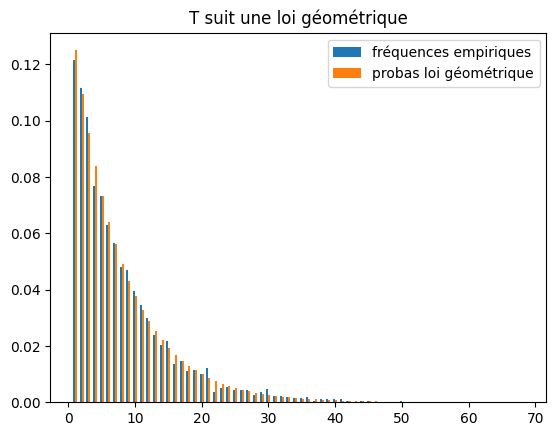

In [289]:
def diagramme_batons(N): # N est la taille de l'échantillon 
    T=np.array([temps_abs_mu() for _ in range (N)])
    F=np.zeros(max(T)-min(T)+1)
    for i in range (N): 
        F[T[i]-1]+=1
    F=F/N
    t=np.arange(min(T),max(T)+1)
    plt.bar(t-0.15,F,0.3,label='fréquences empiriques')
    plt.bar(t+0.15,stats.geom.pmf(t,1-l,loc=0),0.3,label='probas loi géométrique')
    plt.title('T suit une loi géométrique')
    plt.legend() 
    plt.show()

diagramme_batons(5000)

In [257]:
N=300
m=16 # je bricole mon m jusqu'à temps d'avoir la condition des N*proba supérieur à 5 sur toutes les cas 
P_th=np.array(list(stats.geom.pmf(np.arange(1,m+1),1-l))+[1-stats.geom.cdf(m,1-l)])
print([N*P_th<5])

P_emp=np.zeros(m+1) # P va être un tableau d'estimation des P(T=k) pour k entre 1 et m, et la dernière case est une estimation de P(T>m)
for _ in range (N): 
    t=temps_abs_mu()
    if t <=m: 
        P_emp[t-1]+=1
        c+=1
    else : 
        P_emp[m]+=1 
P_emp=P_emp/N

D,p=stats.chisquare(N*P_emp,N*P_th) 
#Avec la p-valeur p : 
alpha=0.05
print(p)
if p<=alpha:
    print("On rejette H0")
else:
    print("On ne rejette pas H0")

[array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False])]
0.9805412025159946
On ne rejette pas H0


In [135]:
def estim_esp(N):  # N est le nombre d'échantillons utilisés pour estimer l'espérance
    T=[]
    for _ in range (N): 
        T.append(temps_abs_mu())
    T=np.array(T)
    print('Espérance attendue :',e)
    print('Espérance estimée:',np.mean(T))

estim_esp(5000)

Espérance attendue : 8.014
Espérance estimée: 8.0144


# Illustration théorème 7 

On va faire 2 illustrations : une illustration de la convergence de $\mu^n$ vers $\mu$ (impliqué par la convergence en variation totale), et une illustration de la convergence exponentielle (en traçant le log de la distance en variation totale en fonction de $n$). 

Tout comme pour l'illustration du théorème 2, on a le choix entre utiliser la méthode de Monte-Carlo et le calcul matriciel. Pour le coup, j'aurai tendance à préférer le calcul matriciel, parce que côté apports mathématiques, ça permet de raconter 2-3 trucs sur le lien entre tout ça et $\tilde P$ donc je trouve ça pas mal. (Mais je propose tout de même une alternative Monte-Carlo pour les fans de la méthode.)

Comment calculer $\mu^n$ matriciellement ? Pour $i \in \{1,\dots,6\}$, on a 
$$\mu^n_i= \mathbb P( X_n=i | X_n \neq N)= \frac{\mathbb P( X_n=i \cap X_n \neq N)}{1- \mathbb P(X_n=N)}.$$
D'une part, on a 
$$\mathbb P(X_n=N)= (\mu_{0,e} P^n)_N,$$
où $\mu_0$ est la loi initiale sur $\{1,\dots,6\}$, et où $\mu_{0,e}$ est le vecteur $(\mu_0 \hspace{4pt} 0)$. Et d'autre part on a 
$$ P( X_n=i \cap X_n \neq N) = \sum_{k=1}^{N-1} \mathbb P(X_0=k) \mathbb P ( X_0=k \cap X_n=i \cap X_n \neq X_N) = \sum_{k=1}^{N-1} \mathbb P(X_0=k) \mathbb P ( X_0=k \cap X_n=i \cap\{ \text{X ne rencontre pas N avant n}\}), $$
et finalement 
$$P( X_n=i \cap X_n \neq N) = ( \mu_0 \tilde{P}^n)_i.$$
Ainsi, 
$$\mu^n_i= \frac {( \mu_0 \tilde{P}^n)_i}{1-(\mu_{0,e} P^n)_N}.$$

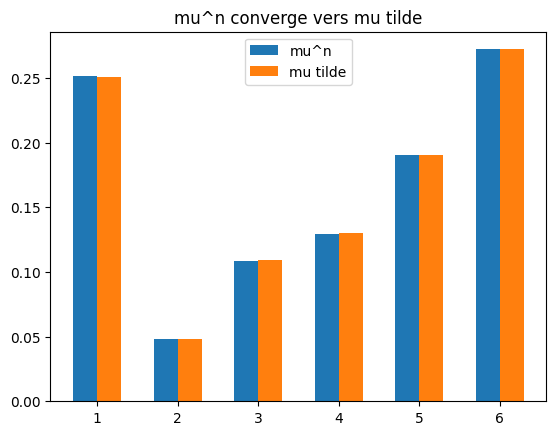

In [201]:
def calcul_mu_n(n): 
    Pt=P[:-1,:-1]
    Pn=np.linalg.matrix_power(P,n)
    Ptn=np.linalg.matrix_power(Pt,n)
    mu0=np.ones(len(P)-1)/(len(P)-1) # on peut mettre ce que l'on veut comme loi initiale, ici je mets la loi uniforme sur {1,...,6}
    mu0e=np.array(list(mu0)+[0]) # on l'étend en une proba initiale sur {1,...,7} comme annoncé ci dessus
    pN=1-mu0e.dot(Pn)[-1] # Proba que X_n soit différent de N 
    pint=mu0.dot(Ptn) # Vecteur des P(X_n=i \cap X_n \neq N)
    mun=pint/pN
    return(mun)

mun=calcul_mu_n(10)
plt.bar(np.arange(1,len(P))-0.15,mun,0.3,label='mu^n')
plt.bar(np.arange(1,len(P))+0.15,mu,0.3,label='mu tilde')
plt.title('mu^n converge vers mu tilde')
plt.legend() 
plt.show()

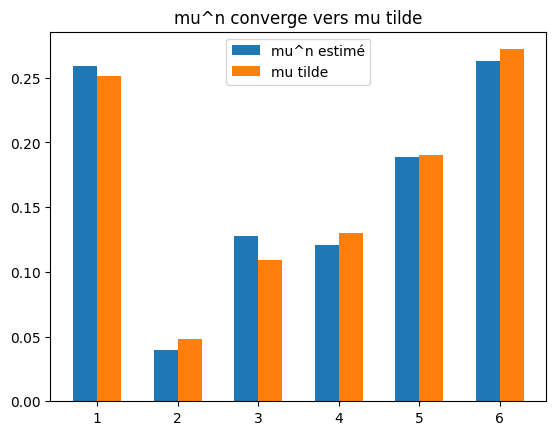

In [292]:
# version Monte-Carlo 
def estim_mu_n(n,N): # N est la taille de l'échantillon utilisé pour l'estimation 
    c=0 # On met un compteur pour avoir N échantillons qui ont au moins "survécu" jusqu'à N 
    mun=np.zeros(len(mu))
    while c<N : 
        X=trajectoire(n)
        if X[-1]!=6 : 
            mun[X[-1]]+=1
            c+=1
    return(mun/N)

mun=estim_mu_n(10,1000)
plt.bar(np.arange(1,len(P))-0.15,mun,0.3,label='mu^n estimé')
plt.bar(np.arange(1,len(P))+0.15,mu,0.3,label='mu tilde')
plt.title('mu^n converge vers mu tilde')
plt.legend() 
plt.show()  

In [298]:
p=0.191

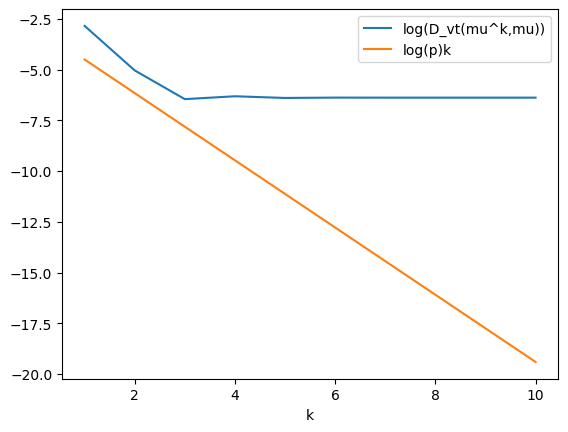

In [306]:
def convergence_exp(n): 
    # on va tracer le log de la distance en variation totale entre mu^k et mu en fonction de k, on devrait trouver quelque chose de sous linéaire 
    # on va tracer cela sur [1,n]
    D=[]
    for k in range (1,n+1): 
        muk=calcul_mu_n(k)
        d=np.sum(abs(muk-mu))
        D.append(d)
    D=np.array(D)
    plt.plot(np.arange(1,n+1),np.log(D),label='log(D_vt(mu^k,mu))')
    plt.plot(np.arange(1,n+1),log(p)*np.arange(1,n+1)+np.log(D[0]),label='log(p)k')
    plt.xlabel('k')
    plt.legend()
    plt.show()

convergence_exp(10)

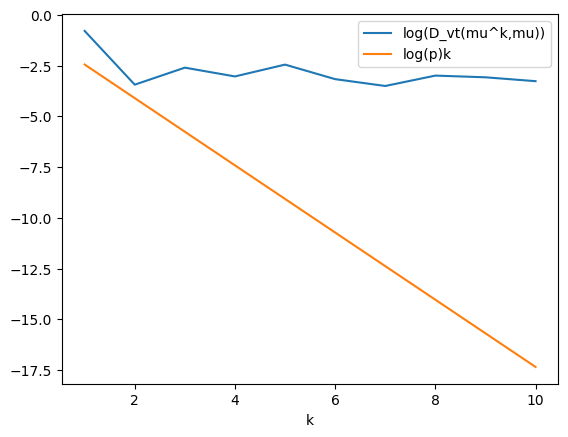

In [308]:
def convergence_exp_Monte_Carlo(n,N): 
    # on va tracer le log de la distance en variation totale entre mu^k et mu en fonction de k, on devrait trouver quelque chose de sous linéaire 
    # on va tracer cela sur [1,n]
    D=[]
    for k in range (1,n+1): 
        muk=estim_mu_n(k,N)
        d=np.sum(abs(muk-mu))
        D.append(d)
    D=np.array(D)
    plt.plot(np.arange(1,n+1),np.log(D),label='log(D_vt(mu^k,mu))')
    p=0.191
    plt.plot(np.arange(1,n+1),log(p)*np.arange(1,n+1)+np.log(D[0]),label='log(p)k')
    plt.legend()
    plt.xlabel('k')
    plt.show()

convergence_exp_Monte_Carlo(10,1000)

Bon les deux flop de la même façon... Je ne sais pas trop quoi en penser, si vous avez repéré une erreur, n'hésitez pas à me contacter !